# LAB 4: Gram-Schmidt and Eigenvalues & Eigenvectors



In this lab you will use Python to study the following topics:

- The Gram-Schmidt Algorithm to change an independent set of vectors into anorthonormal set.

- Determination of eigenvalues and eigenvectors using the characteristic polynomial of a matrix

- Use of eigenvectors to transform a matrix to diagonal form.


# First: you should run this cell

In [1]:
# Make all numpy available via shorter 'np' prefix
import numpy as np
# Make all sympy available via shorter 'sym' prefix
import sympy as sym

import math


#import plotter
import matplotlib.pyplot as plt


def rvect(m):
    return np.fix((10 * (np.random.rand(m, 1))))


def rmat(m, n):
    return np.fix((10 * (np.random.rand(m, n))))

#  Question 1 : Gram-Schmidt Orthogonalization

#### Generate three random vectors in $R^3$ by

- `u1 = np.array([[4], [9], [6]])`
- `u2 = np.array([[6], [8], [8]])`
- `u3 = np.array([[0], [9], [6]])`

- Check whether they are linearly independent by calculating `np.linalg.matrix_rank(np.block([u1, u2, u3]))`.
- If the answer is not 3, then generate a new random set of vectors and calculate the rank. Repeat until the rank is 3. Now use these vectors in the following calculations.

In [4]:
#type your code here:
u1=np.array([[4],[9],[6]])
u2=np.array([[6],[8],[8]])
u3=np.array([[0],[9],[6]])
np.linalg.matrix_rank(np.block([u1,u2,u3]))
print(f"u1=\n{u1}\n")
print(f"u2=\n{u2}\n")
print(f"u3=\n{u3}\n")
print(f"-----------------{np.linalg.matrix_rank(np.block([u1,u2,u3]))}---------------")

u1=
[[4]
 [9]
 [6]]

u2=
[[6]
 [8]
 [8]]

u3=
[[0]
 [9]
 [6]]

-----------------3---------------


#### Plot the three vectors in the graphics window as red, green, and blue dotted lines by the commands:
- `r = np.arange(0, 1, 0.05)`
- `ax = plt.axes(projection='3d')`
- `ax.plot3D(r * u1[0], r * u1[1], r * u1[2], 'r:')`
- `ax.plot3D(r * u2[0], r * u2[1], r * u2[2], 'g:')`
- `ax.plot3D(r * u3[0], r * u3[1], r * u3[2], 'b:')`

#### Determine visually whether the vectors are mutually orthogonal or not.

### ---------------------------------------------------Write your answer here--------------------------------------------







### --------------------------------------------------------------------------------------------------------------------------------

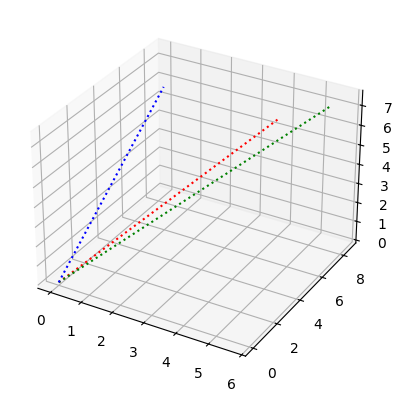

In [5]:
#type your code here
r=np.arange(0,1,0.05)
ax=plt.axes(projection='3d')
ax.plot3D(r*u1[0],r*u1[1],r*u1[2],'r:')
ax.plot3D(r*u2[0],r*u2[1],r*u2[2],'g:')
ax.plot3D(r*u3[0],r*u3[1],r*u3[2],'b:')


#### (b) Now use the vectors u1, u2, u3 to obtain an orthogonal basis for R3, following the Gram-Schmidt algorithm. Set `v1 = u1`. Obtain v2 by removing the component of u2 in the direction v1:


\\[v_2 = u_2 - \frac{v_1 \cdot u_2}{v_1 \cdot v_1}v_1\\]

- Calculate the dot product to check that the vectors v1 and v2 are mutually orthogonal (within a negligible numerical error). Also add v2 to your graphics window as a dashed-dotted green line.

In [47]:
#type your code here
v1=u1

v2=u2-((v1.T@u2)/(v1.T@v1))*v1

print(f"v1=\n{v1}\n")
print(f"v2=\n{v2}\n")
print(f"-----------------{v1.T@v2}---------------")


v1=
[[4]
 [9]
 [6]]

v2=
[[ 1.66917293]
 [-1.7443609 ]
 [ 1.5037594 ]]

-----------------[[0.]]---------------


#### Now obtain v3 by removing the components of u3 in the directions of v1 and v2:

\\[v_3 = u_3 - \frac{v_1 \cdot u_3}{v_1 \cdot v_1}v_1 - \frac{v_2 \cdot u_3}{v_2 \cdot v_2}v_2\\\\]
- Calculate dot products by python to check that v3 is orthogonal to the vectors v1 and v2 (within a negligible numerical error). Add v3 to your plot as a dashed-dotted blue line by

v3=
[[-2.14126394]
 [-0.35687732]
 [ 1.96282528]]

-----------------[[-3.55271368e-15]]---------------
-----------------[[0.]]---------------


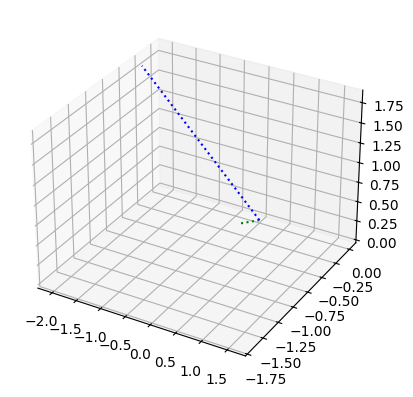

In [48]:
#type your code here
v3=u3-((v1.T@u3)/(v1.T@v1))*v1-((v2.T@u3)/(v2.T@v2))*v2
print(f"v3=\n{v3}\n")
print(f"-----------------{v3.T@v1}---------------")
print(f"-----------------{v3.T@v2}---------------")
r=np.arange(0,1,0.05)
ax=plt.axes(projection='3d')
ax.plot3D(r*v2[0],r*v2[1],r*v2[2],'g:')
ax.plot3D(r*v3[0],r*v3[1],r*v3[2],'b:')

#### Add v3 to your plot as a dashed-dotted blue line. Obtain a good alignment of the graph that shows orthogonality in perspective using:
- `ax.view_init(angle1, angle2)`

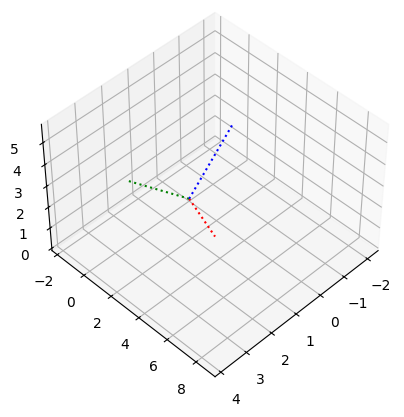

In [49]:
#type your code here
ax=plt.axes(projection='3d')
ax.plot3D(r*v1[0],r*v1[1],r*v1[2],'r:')
ax.plot3D(r*v2[0],r*v2[1],r*v2[2],'g:')
ax.plot3D(r*v3[0],r*v3[1],r*v3[2],'b:')
ax.view_init(45,45)

#### (c) The last step in the Gram-Schmidt algorithm is to rescale the vectors v1, v2, v3 to obtain an orthonormal basis for R3:

- `w1 = v1 / np.linalg.norm(v1)`
- `w2 = v2 / np.linalg.norm(v2)`
- `w3 = v3 / np.linalg.norm(v3)`

#### Define the matrix Q = [w1, w2, w3] and give written answers to the following questions.



- What is the inverse matrix Q Now.

In [41]:
#type your code here:
w1=v1/np.linalg.norm(v1)
w2=v2/np.linalg.norm(v2)
w3=v3/np.linalg.norm(v3)
Q=np.hstack((w1,w2,w3))
print(f"w1=\n{w1}\n")
print(f"w2=\n{w2}\n")
print(f"w3=\n{w3}\n")
print(f"Q=\n{Q}\n")
print(f"-----------------Inverse of Q:\n{np.linalg.inv(Q)}---------------")
print(f"-----------------Transpose of Q:\n{Q.T}---------------")

w1=
[[0.34684399]
 [0.78039897]
 [0.52026598]]

w2=
[[ 0.58684177]
 [-0.61327608]
 [ 0.52868628]]

w3=
[[-0.73165291]
 [-0.12194215]
 [ 0.67068184]]

Q=
[[ 0.34684399  0.58684177 -0.73165291]
 [ 0.78039897 -0.61327608 -0.12194215]
 [ 0.52026598  0.52868628  0.67068184]]

-----------------Inverse of Q:
[[ 0.34684399  0.78039897  0.52026598]
 [ 0.58684177 -0.61327608  0.52868628]
 [-0.73165291 -0.12194215  0.67068184]]---------------
-----------------Transpose of Q:
[[ 0.34684399  0.78039897  0.52026598]
 [ 0.58684177 -0.61327608  0.52868628]
 [-0.73165291 -0.12194215  0.67068184]]---------------


# Question 2. Eigenvectors and Diagonalization

#### (a) Generate a random 3 * 3 integer matrix and test whether its eigenvalues are all real by the commands

- `A = rmat(3,3)`
- Use [numpy.linalg.eig](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) to obtain the eigenvalues of `A` as follows:
    - `w, v = np.linalg.eig(A)`. Where `w` are the eigenvalues and `v`the normalized (unit “length”) eigenvectors, such that the column `v[:,i]` is the eigenvector corresponding to the eigenvalue `w[i]`.
- `z = w - w.real`

If any entry in the vector z is not zero, then the eigenvalues of A are not all real. In this case repeat these commands until you get an A for which z has all zeros.

<div class="alert alert-warning">
    <h4>
        If you generated any matrices with complex eigenvalues, be very careful here! don't use it for the next questions!
    </h4>
</div>

In [50]:
#type your code here:
A=rmat(3,3)
w,v=np.linalg.eig(A)
z=w-w.real
print(f"A=\n{A}\n")
print(f"w=\n{w}\n")
print(f"v=\n{v}\n")
print(f"z=\n{z}\n")

A=
[[9. 2. 1.]
 [7. 4. 8.]
 [4. 7. 2.]]

w=
[14.00640316  5.6118279  -4.61823106]

v=
[[ 0.40161858  0.53268042  0.05077996]
 [ 0.72661515 -0.60809932 -0.70129619]
 [ 0.55743425 -0.5886143   0.71105911]]

z=
[0. 0. 0.]



#### Now calculate the characteristic polynomial p(t) of your matrix A by

- Symbolic computations are done with `Symbol` class in `sympy`. Read the [documentation](https://docs.sympy.org/latest/gotchas.html#introduction) for many different examples.
- `from sympy.abc import t`
- `I = np.eye(3)`
- `p = sym.det(sym.Matrix(A - t * I))`
- `sym.solve(p)`


#### Plot the characteristic polynomial of A in a graphics window

- `p1 = sym.plot(p, (t, -10, 10), show=False)`
- `p1.show()`

- Adjust the horizontal range of the plot (change [ -10,10] if needed).
- View the graph with a range that shows all three real roots, and include the graph in your lab report. Use the graph to obtain approximate values for the three real roots of p(t).


p=
-1.0*t**3 + 15.0*t**2 + 25.0*t - 250.0



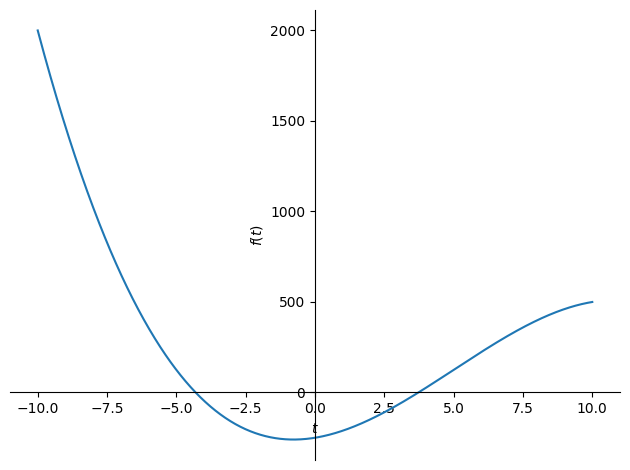

In [43]:
#typr your code here:
from sympy.abc import t
I=np.eye(3)
p=sym.det(sym.Matrix(A-t*I))
sym.solve(p)
print(f"p=\n{p}\n")
p1=sym.plot(p,(t,-10,10),show=False)
p1.show()

#### (b)Use the python to generate a matrix P and a diagonal matrix D.

- `w, P = np.linalg.eig(A)`
- `D = np.linalg.diag(w)`

- Compare the diagonal entries of D with your graphical estimates for the eigenvalues of A in part (a).

#### Use python to define (the columns of P).

- `p1 = P[:, [0]]`
- `p2 = P[:, [1]]`
- `p3 = P[:, [2]]`

#### Calculate

- `A @ p1 - D[0, 0] * p1`
- `A @ p2 - D[1, 1] * p2`
- `A @ p3 - D[2, 2] * p3`

#### What does this calculation tell you about the eigenvalues and eigenvectors of A?

### ---------------------------------------------------Write your answer here------------------------------------







### ------------------------------------------------------------------------------------------------------------------------

In [44]:
#type your code here:
W,P=np.linalg.eig(A)
D=np.diag(W)
print(f"W=\n{W}\n")
print(f"P=\n{P}\n")
print(f"D=\n{D}\n")
P1=P[:,[0]]
P2=P[:,[1]]
P3=P[:,[2]]
print(f"A@p1-D[0,0]*p1=\n{A@P1-D[0,0]*P1}\n")
print(f"A@p2-D[1,1]*p2=\n{A@P2-D[1,1]*P2}\n")
print(f"A@p3-D[2,2]*p3=\n{A@P3-D[2,2]*P3}\n")

W=
[15.57453771 -4.30402927  3.72949156]

P=
[[-0.55674671 -0.73474945  0.05408864]
 [-0.58981187  0.28894602 -0.97510109]
 [-0.58494022  0.61372099  0.21506342]]

D=
[[15.57453771  0.          0.        ]
 [ 0.         -4.30402927  0.        ]
 [ 0.          0.          3.72949156]]

A@p1-D[0,0]*p1=
[[-1.59872116e-14]
 [-1.77635684e-15]
 [ 1.77635684e-15]]

A@p2-D[1,1]*p2=
[[8.88178420e-16]
 [3.55271368e-15]
 [3.10862447e-15]]

A@p3-D[2,2]*p3=
[[1.58206781e-15]
 [1.33226763e-15]
 [9.99200722e-16]]



#### (c) Let A, P, D be as in part (b).

- Verify by python that `A = P @ D @ np.linalg.inv(P)`.
- Use this formula for A to express A<sup>5</sup> and A<sup>10</sup> symbolically in terms of P, P<sup>-1</sup>, D<sup>5</sup> and D<sup>10</sup>.
- Verify your answer to this question numerically using python. Hint: use `np.linalg.matrix_power(A, 5)` to calculate A<sup>5</sup>.

### ---------------------------------------------------Write your answer here------------------------------------







### ------------------------------------------------------------------------------------------------------------------------

In [51]:
#type your code here:
np.linalg.matrix_power(A, 5)
P @ np.linalg.matrix_power(D, 5) @ np.linalg.inv(P)

array([[377625., 109625., 402250.],
       [401125., 116625., 424625.],
       [398375., 114875., 421375.]])